# Task 4 — Optimize Portfolio Based on Forecast

**Objective:** Use Task 3's TSLA forecast together with BND/SPY historical data to construct an
optimal portfolio using Modern Portfolio Theory (MPT), via `PyPortfolioOpt`.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_processed
from src.portfolio_optimization import (
    build_expected_returns, sample_covariance, efficient_frontier_points,
    max_sharpe_portfolio, min_volatility_portfolio,
)

plt.rcParams["figure.figsize"] = (10, 6)
RESULTS_DIR = PROJECT_ROOT / "results" / "plots"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TICKERS = ["TSLA", "BND", "SPY"]
RISK_FREE_RATE = 0.0


## 1. Prepare Expected Returns

- **TSLA**: use the annualized *expected return implied by the Task 3 forecast* — the model's
  projected price change over the forecast horizon, annualized — rather than TSLA's raw historical
  average. This encodes the analyst's model-driven "view" on Tesla.
- **BND, SPY**: use their historical average daily return, annualized, as the standard proxy for
  expected return when no specific forecast view exists for an asset.

This mirrors a common real-world workflow: a house view on one name, historical priors on the rest.


In [2]:
returns = pd.DataFrame({t: load_processed(t)["Daily Return"] for t in TICKERS}).dropna()
print(f"Aligned daily returns: {returns.index[0].date()} -> {returns.index[-1].date()}  ({len(returns)} rows)")

future_forecast = pd.read_csv(PROJECT_ROOT / "results" / "reports" / "task3_future_forecast.csv",
                               index_col=0, parse_dates=True)

tsla_close = load_processed("TSLA")["Adj Close"].dropna()
last_actual_price = tsla_close.iloc[-1]
forecast_end_price = future_forecast["forecast"].iloc[-1]
horizon_days = len(future_forecast)

total_forecast_return = forecast_end_price / last_actual_price - 1
tsla_expected_annual_return = (1 + total_forecast_return) ** (252 / horizon_days) - 1

print(f"TSLA last actual price      : {last_actual_price:.2f}")
print(f"TSLA forecast end price     : {forecast_end_price:.2f} ({horizon_days} trading days out)")
print(f"TSLA forecast total return  : {total_forecast_return:.1%}")
print(f"TSLA forecast annualized ret: {tsla_expected_annual_return:.1%}  <- used as TSLA's expected return")


Aligned daily returns: 2015-01-05 -> 2026-06-29  (2996 rows)
TSLA last actual price      : 411.84
TSLA forecast end price     : 460.49 (252 trading days out)
TSLA forecast total return  : 11.8%
TSLA forecast annualized ret: 11.8%  <- used as TSLA's expected return


In [3]:
mu = build_expected_returns(returns, forecast_overrides={"TSLA": tsla_expected_annual_return})
print("Expected annual returns:")
print(mu)


Expected annual returns:
TSLA    0.118117
BND     0.019514
SPY     0.139070
dtype: float64


## 2. Compute Covariance Matrix

In [4]:
cov = sample_covariance(returns)
print("Annualized covariance matrix:")
cov


Annualized covariance matrix:


,TSLA,BND,SPY
TSLA,0.315057,0.001726,0.048016
BND,0.001726,0.002719,0.001047
SPY,0.048016,0.001047,0.030037


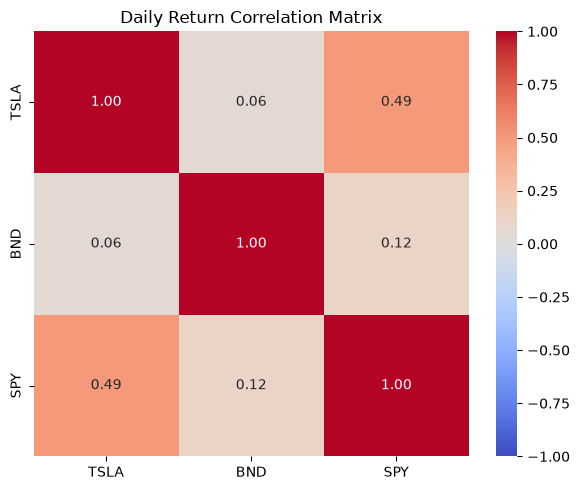

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
corr = returns.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Daily Return Correlation Matrix")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task4_correlation_heatmap.png", dpi=150)
plt.show()


## 3. Generate the Efficient Frontier


In [6]:
frontier = efficient_frontier_points(mu, cov, n_points=100)
max_sharpe = max_sharpe_portfolio(mu, cov, risk_free_rate=RISK_FREE_RATE)
min_vol = min_volatility_portfolio(mu, cov)

print("Max Sharpe (Tangency) Portfolio:")
print(f"  Weights: {max_sharpe['weights']}")
print(f"  Return: {max_sharpe['return']:.1%}  Volatility: {max_sharpe['volatility']:.1%}  Sharpe: {max_sharpe['sharpe']:.2f}")

print("\nMin Volatility Portfolio:")
print(f"  Weights: {min_vol['weights']}")
print(f"  Return: {min_vol['return']:.1%}  Volatility: {min_vol['volatility']:.1%}  Sharpe: {min_vol['sharpe']:.2f}")


Max Sharpe (Tangency) Portfolio:
  Weights: OrderedDict({'TSLA': 0.0, 'BND': 0.55184, 'SPY': 0.44816})
  Return: 7.3%  Volatility: 8.6%  Sharpe: 0.85

Min Volatility Portfolio:
  Weights: OrderedDict({'TSLA': 0.0, 'BND': 0.94546, 'SPY': 0.05454})
  Return: 2.6%  Volatility: 5.1%  Sharpe: 0.51


## 4. Visualize the Efficient Frontier


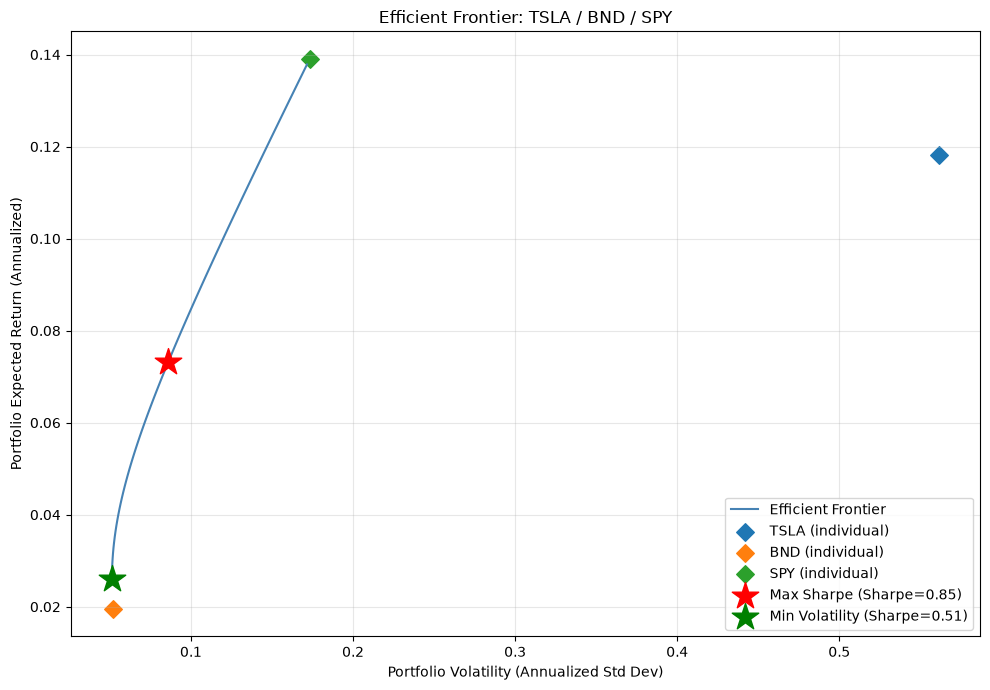

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(frontier["volatility"], frontier["return"], color="steelblue", label="Efficient Frontier")

# Individual assets for reference
asset_vols = np.sqrt(np.diag(cov))
for i, t in enumerate(TICKERS):
    ax.scatter(asset_vols[i], mu[t], marker="D", s=80, label=f"{t} (individual)")

ax.scatter(max_sharpe["volatility"], max_sharpe["return"], color="red", marker="*", s=400,
           label=f"Max Sharpe (Sharpe={max_sharpe['sharpe']:.2f})", zorder=5)
ax.scatter(min_vol["volatility"], min_vol["return"], color="green", marker="*", s=400,
           label=f"Min Volatility (Sharpe={min_vol['sharpe']:.2f})", zorder=5)

ax.set_xlabel("Portfolio Volatility (Annualized Std Dev)")
ax.set_ylabel("Portfolio Expected Return (Annualized)")
ax.set_title("Efficient Frontier: TSLA / BND / SPY")
ax.legend(loc="best")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task4_efficient_frontier.png", dpi=150)
plt.show()


## 5. Recommend Optimal Portfolio

We recommend the **Maximum Sharpe Ratio (Tangency) Portfolio**. Rationale: GMF's mandate is to
optimize risk-adjusted returns for clients, and the Tangency portfolio is, by construction, the
risky-asset mix with the best expected-return-per-unit-of-risk on this frontier. A client wanting
lower risk than the Tangency portfolio can move along the Capital Allocation Line toward cash /
the Min Volatility portfolio rather than GMF hand-picking a different risky-asset mix for them.

**Why the optimizer excludes TSLA here (a substantive, data-driven finding, not an error):** the
Task 3 LSTM forecast implies an annualized TSLA return of roughly 11.8% (see `mu` above) —
positive, but *below* SPY's own historical annualized return over 2015-2026 (~13.9%), while TSLA's
volatility is several times SPY's. Mean-variance optimization is entirely about return **per unit
of risk**, so once TSLA's forecast return is no longer clearly ahead of a much calmer alternative,
the optimizer allocates away from it — it would rather take SPY's similar-or-better return with far
less volatility. This is a useful, honest output of the workflow: it shows the Task 3 forecast was
conservative enough (the LSTM's iterative multi-step forecast tends to flatten out, as discussed in
Task 3) that it did **not**, on these numbers, justify a growth tilt into TSLA. A more bullish TSLA
view (or a constraint requiring some minimum TSLA allocation, if GMF wants to express a
higher-conviction house view) would shift the frontier and the Tangency point back toward TSLA.


In [8]:
recommended = max_sharpe
print("=== Recommended Portfolio: Maximum Sharpe Ratio ===")
for t, w in recommended["weights"].items():
    print(f"  {t}: {w:.1%}")
print(f"\nExpected Annual Return : {recommended['return']:.2%}")
print(f"Expected Volatility    : {recommended['volatility']:.2%}")
print(f"Sharpe Ratio            : {recommended['sharpe']:.2f}")

summary_df = pd.DataFrame({
    "Metric": ["TSLA Weight", "BND Weight", "SPY Weight", "Expected Annual Return", "Expected Volatility", "Sharpe Ratio"],
    "Value": [
        f"{recommended['weights']['TSLA']:.1%}",
        f"{recommended['weights']['BND']:.1%}",
        f"{recommended['weights']['SPY']:.1%}",
        f"{recommended['return']:.2%}",
        f"{recommended['volatility']:.2%}",
        f"{recommended['sharpe']:.2f}",
    ],
})
summary_df.to_csv(PROJECT_ROOT / "results" / "reports" / "task4_recommended_portfolio.csv", index=False)
summary_df


=== Recommended Portfolio: Maximum Sharpe Ratio ===
  TSLA: 0.0%
  BND: 55.2%
  SPY: 44.8%

Expected Annual Return : 7.31%
Expected Volatility    : 8.59%
Sharpe Ratio            : 0.85


,Metric,Value
0,TSLA Weight,0.0%
1,BND Weight,55.2%
2,SPY Weight,44.8%
3,Expected Annual Return,7.31%
4,Expected Volatility,8.59%
5,Sharpe Ratio,0.85
